In [1]:
## Use this to price any symbol call option that may be experiencing correlated industry returns... 
## fill in a symbol in line 2 and etf in 3. Use the PULLIV file to get the correct Implied volatility 

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import time

start = time.time()

In [3]:
STOCK = yf.download("INTC", start = "2007-01-01") ## < -- put your desired stock symbol and start date here 

[*********************100%***********************]  1 of 1 completed


In [4]:
ETF = yf.download("IYW", start = "2007-01-01")  ## <-- put your desired correlated etf here 

[*********************100%***********************]  1 of 1 completed


In [5]:
S0 = 105.15 #current price
K = 106 #strike price
r = 0.038 #us tbill to closest T 
T = 6/252 #working days to expiration / 252 working days per year
n_steps = 6 #working days to expiration
n_simulations = 100000
STOCK_IV = 0.66  ## <- pull from the other file 

In [6]:
STOCK.shape

(4937, 5)

In [7]:
ETF.shape

(4934, 5)

In [8]:
STOCK.describe()

Price,Close,High,Low,Open,Volume
Ticker,INTC,INTC,INTC,INTC,INTC
count,4937.000000,4937.000000,4937.000000,4937.000000,4.937000e+03
mean,29.036704,29.436192,28.626588,29.029825,4.831445e+07
std,16.868989,17.273286,16.449576,16.888220,3.430840e+07
min,7.641387,7.989297,7.550951,7.688691,5.893800e+06
25%,15.657342,15.757191,15.474306,15.610247,2.562520e+07
50%,25.571920,25.879396,25.305361,25.527134,3.856350e+07
75%,40.475010,41.086056,39.982416,40.467876,6.030000e+07
max,140.940002,142.350006,136.210007,139.729996,5.239080e+08


In [9]:
ETF.describe()

Price,Close,High,Low,Open,Volume
Ticker,IYW,IYW,IYW,IYW,IYW
count,4934.000000,4934.000000,4934.000000,4934.000000,4.934000e+03
mean,55.709699,56.139532,55.213930,55.694101,9.955142e+05
std,55.287686,55.734175,54.763883,55.279987,1.369326e+06
min,6.638448,6.981930,6.561385,6.739732,7.960000e+04
25%,15.083353,15.165918,14.966174,15.080756,4.404000e+05
50%,28.001683,28.109389,27.820604,27.966179,6.710000e+05
75%,84.204832,85.074481,83.529675,84.498986,1.132600e+06
max,259.863556,260.933251,256.864438,260.413384,5.211600e+07


In [10]:
STOCK_close = STOCK["Close"].squeeze()

In [11]:
STOCK_returns = np.log(STOCK_close / STOCK_close.shift(1)).dropna()

In [12]:
ETF_close = ETF["Close"].squeeze()

In [13]:
ETF_returns = np.log(ETF_close / ETF_close.shift(1)).dropna()

In [14]:
print(STOCK_returns.shape, ETF_returns.shape)

(4936,) (4933,)


In [15]:
window = 90 

In [16]:
rolling_cov = STOCK_returns.rolling(window).cov(ETF_returns)
rolling_var = ETF_returns.rolling(window).var()
rolling_beta = rolling_cov / rolling_var

In [17]:
print(rolling_beta.dropna().head())
print(rolling_beta.shape)

Date
2007-05-14    1.008897
2007-05-15    0.960470
2007-05-16    0.962443
2007-05-17    0.962177
2007-05-18    0.976839
dtype: float64
(4936,)


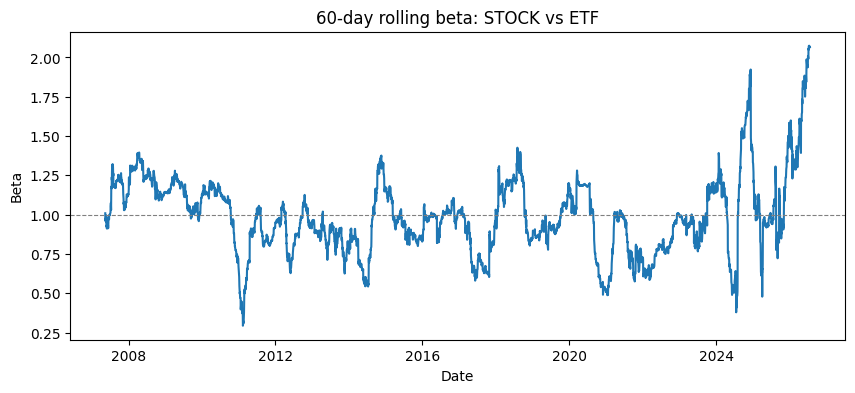

In [18]:
plt.figure(figsize=(10,4))
plt.plot(rolling_beta)
plt.title("60-day rolling beta: STOCK vs ETF")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

In [19]:
rolling_corr = STOCK_returns.rolling(window).corr(ETF_returns)
rolling_r2 = rolling_corr**2
print(rolling_r2)

Date
2007-01-04   NaN
2007-01-05   NaN
2007-01-08   NaN
2007-01-09   NaN
2007-01-10   NaN
              ..
2026-08-12   NaN
2026-08-13   NaN
2026-08-14   NaN
2026-08-17   NaN
2026-08-18   NaN
Length: 4936, dtype: float64


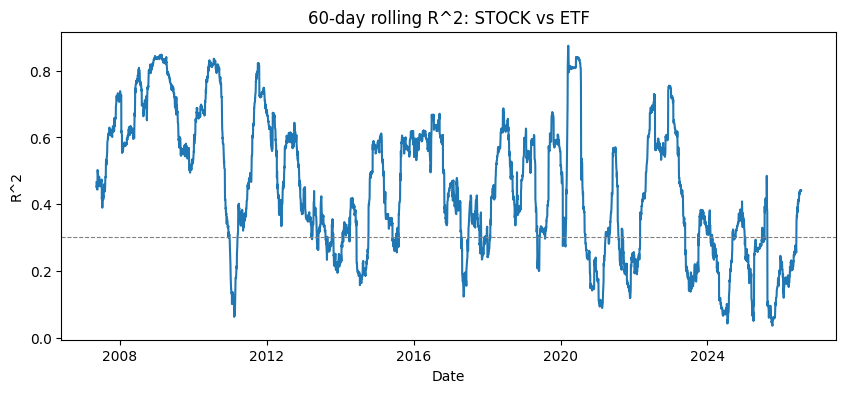

In [20]:
plt.figure(figsize=(10,4))
plt.plot(rolling_r2) 
plt.title("60-day rolling R^2: STOCK vs ETF") 
plt.xlabel("Date") 
plt.ylabel("R^2") 
plt.axhline(0.3, color = 'gray', linestyle = '--', linewidth = 0.8)
plt.show()

In [21]:
current_beta = rolling_beta.dropna().iloc[-1]
current_corr = rolling_corr.dropna().iloc[-1]

In [22]:
print("Current beta:", current_beta)
print("Current correlation:", current_corr)

Current beta: 2.064344973236104
Current correlation: 0.6639286728305381


In [23]:
ETF_daily_std = ETF_returns.std()
ETF_sigma = ETF_daily_std * np.sqrt(252)
print(ETF_sigma)

0.23937340229140472


In [24]:
STOCK_daily_std = STOCK_returns.std()
STOCK_V = STOCK_daily_std * np.sqrt(252)
print("The stock's realised volatility is:", STOCK_V, "but its implied volatility is:", STOCK_IV)

The stock's realised volatility is: 0.3855894027738724 but its implied volatility is: 0.66


In [25]:
dt = T/n_steps

In [26]:
np.random.normal()

0.3192352103601806

In [27]:
Z1 = np.random.normal(size = (n_simulations, n_steps))

Z2 = np.random.normal(size = (n_simulations, n_steps))

print("Z1's shape:",Z1.shape)
print("Z2's shape:",Z2.shape)

Z1's shape: (100000, 6)
Z2's shape: (100000, 6)


In [28]:
Z_STOCK = current_corr * Z1 + np.sqrt(1 - current_corr**2) * Z2
print(Z_STOCK)

[[-0.78683294  1.30517852 -1.1952372   0.02862099  1.12522728  1.22111132]
 [-0.29894377 -1.50310263  1.46517963  0.98254737 -1.00173607 -0.97285421]
 [ 0.87367395 -0.78045237  0.75675253 -1.46107018  0.75138914 -0.94039815]
 ...
 [-0.19165087 -0.71315584  1.28613451 -0.25569895  0.6522638   0.31587778]
 [ 0.95799259  0.57324149 -0.6276078   0.05409407 -0.43356045  0.25204876]
 [-0.09930382  0.45381305  0.38305809  1.75144662  0.67082611  1.62539427]]


In [29]:
print(np.corrcoef(Z1.flatten(), Z_STOCK.flatten())[0,1])

0.6639625735688558


In [30]:
STOCK_log_returns = (r - 0.5 *STOCK_IV**2)*dt + STOCK_IV*np.sqrt(dt)*Z_STOCK

STOCK_log_returns.shape

(100000, 6)

In [31]:
ETF_log_returns = (r - 0.5 *ETF_sigma**2)*dt + ETF_sigma*np.sqrt(dt)*Z1

ETF_log_returns.shape

(100000, 6)

In [32]:
STOCK_cumulative_log_returns = np.cumsum(STOCK_log_returns, axis = 1)

In [33]:
ETF_cumulative_log_returns = np.cumsum(ETF_log_returns, axis = 1)

In [34]:
STOCK_price_paths = S0 * np.exp(STOCK_cumulative_log_returns)

In [35]:
ETF_price_paths = S0 * np.exp(ETF_cumulative_log_returns)

In [36]:
STOCK_price_paths.shape

(100000, 6)

In [37]:
print(len(STOCK_price_paths))

100000


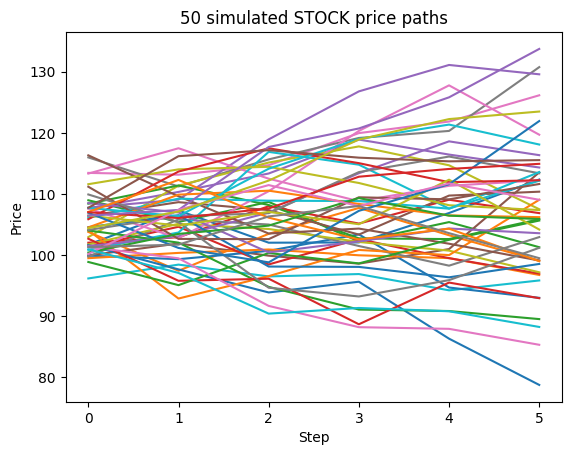

In [38]:
plt.plot(STOCK_price_paths[:50].T)
plt.title("50 simulated STOCK price paths")
plt.xlabel("Step") 
plt.ylabel("Price")
plt.show()

In [39]:
ETF_price_paths.shape

(100000, 6)

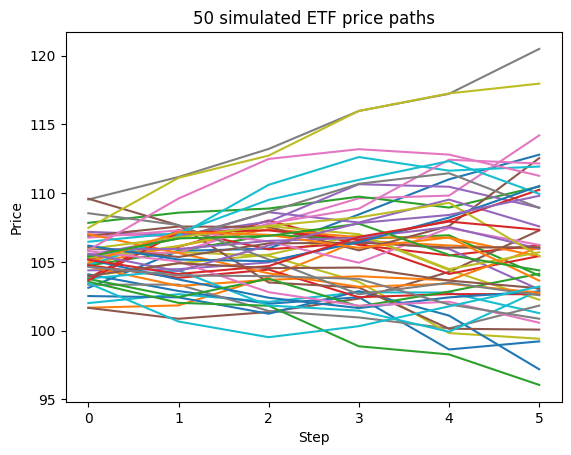

In [40]:
plt.plot(ETF_price_paths[:50].T)
plt.title("50 simulated ETF price paths")
plt.xlabel("Step") 
plt.ylabel("Price")
plt.show()

In [41]:
log_returns_correlated = (r - 0.5 * STOCK_IV**2) * dt + STOCK_IV*np.sqrt(dt)*Z_STOCK 
cumulative_log_returns_correlated = np.cumsum(log_returns_correlated, axis = 1) 
STOCK_price_paths_correlated = S0 * np.exp(cumulative_log_returns_correlated)

In [42]:
final_prices_correlated = STOCK_price_paths_correlated[:,-1] 

In [43]:
payoffs_correlated = np.maximum(final_prices_correlated - K, 0) 

In [44]:
payoffs_correlated.mean()

np.float64(3.9573218091128757)

In [45]:
(payoffs_correlated > 0).sum()

np.int64(45482)

In [46]:
average_payoff = payoffs_correlated.mean()

In [47]:
option_prices = np.exp(-r*T) * average_payoff

In [48]:
print("This is my price:",option_prices)

This is my price: 3.953742994326881


In [49]:
from scipy.stats import norm 

In [50]:
d1 = (np.log(S0/K) + (r + 0.5*STOCK_IV**2)*T) / (STOCK_IV*np.sqrt(T))

In [51]:
d2 = d1 - STOCK_IV*np.sqrt(T)

In [52]:
call_price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

In [53]:
print("BS back test price:", call_price)

BS back test price: 3.919009074467631


In [54]:
end = time.time()
print(f"This version: {end - start:.3f} seconds")

This version: 8.010 seconds


In [55]:
import os
print(os.getcwd())

C:\Users\young\Derivative Pricer
